In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/angle_over_time.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/angle_over_time.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/angle_over_time.csv')
df3['Condition'] = 'GH Starved-Starved'


df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/angle_over_time.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/angle_over_time.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/angle_over_time.csv')
df6['Condition'] = 'SI Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)




In [2]:
condition_order = [
    'GH Fed-Fed', 'GH Fed-Starved', 'GH Starved-Starved',
    'SI Fed-Fed', 'SI Fed-Starved', 'SI Starved-Starved'
]

palette = {
    'GH Fed-Fed': '#2F6F4E',
    'GH Fed-Starved': '#7A5BA6',
    'GH Starved-Starved': '#B84E4E',
    'SI Fed-Fed': '#8BC49A',
    'SI Fed-Starved': '#C3A6D8',
    'SI Starved-Starved': '#E39A93',
}

df['Housing'] = np.where(df['Condition'].str.contains('GH'), 'GH', 'SI')
df['Feeding'] = df['Condition'].str.replace('GH ', '', regex=False).str.replace('SI ', '', regex=False)

df.head()


,time,angle,file,Condition,Housing,Feeding
0,0,156.535708,2026-04-28_12-19-24_td11.tracks.feather,GH Fed-Fed,GH,Fed-Fed
1,0,118.020457,2026-04-28_12-19-24_td11.tracks.feather,GH Fed-Fed,GH,Fed-Fed
2,0,123.213284,2026-06-05_12-11-35_td17.tracks.feather,GH Fed-Fed,GH,Fed-Fed
3,0,158.138962,2026-06-22_12-07-14_td12.tracks.feather,GH Fed-Fed,GH,Fed-Fed
4,0,157.803364,2026-05-18_12-02-50_td17.tracks.feather,GH Fed-Fed,GH,Fed-Fed


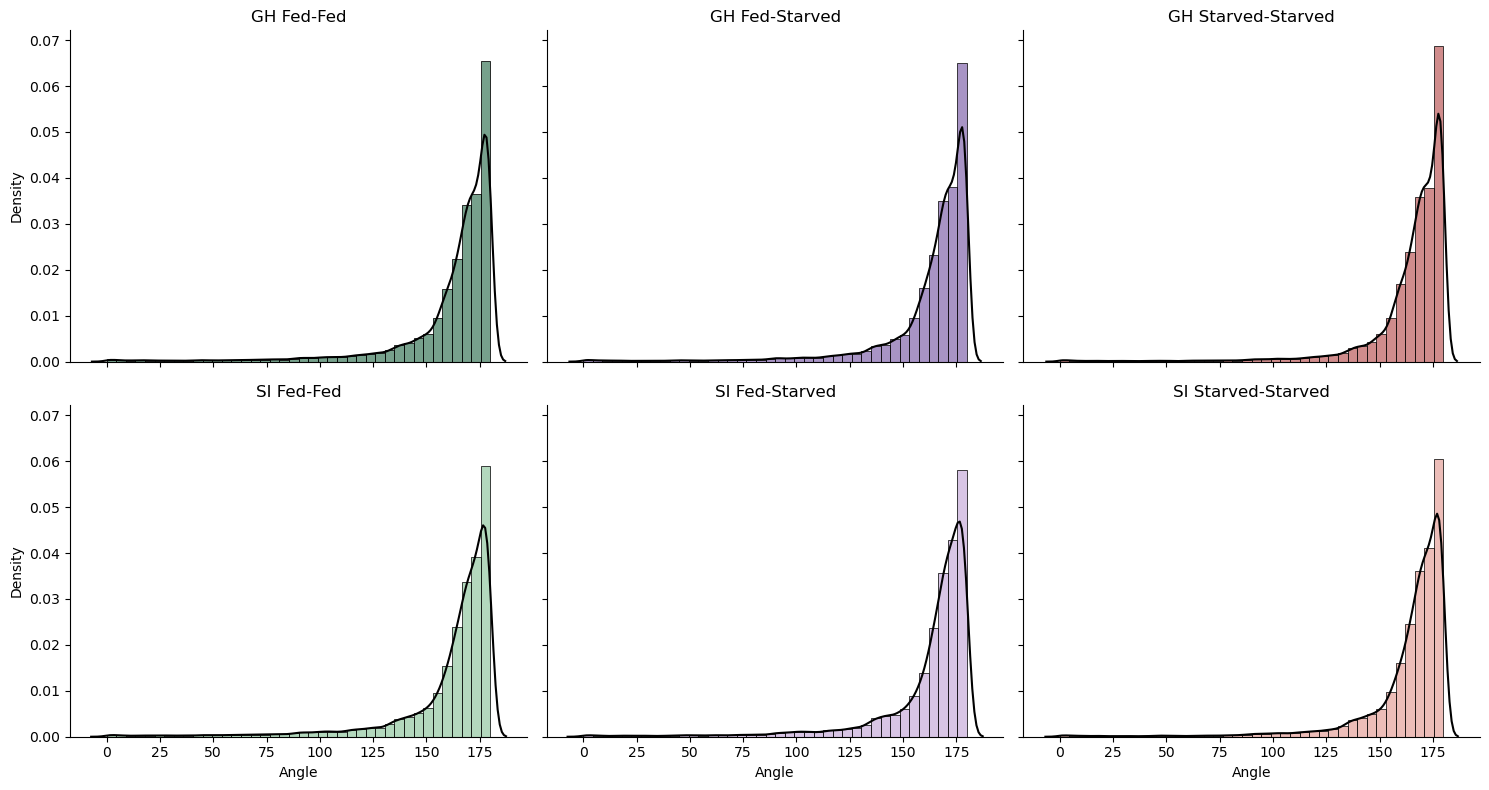

In [3]:
# angle distribution for each condition
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, condition in zip(axes, condition_order):
    sub = df[df['Condition'] == condition]
    sns.histplot(
        data=sub,
        x='angle',
        bins=40,
        stat='density',
        color=palette[condition],
        alpha=0.65,
        ax=ax,
    )
    sns.kdeplot(
        data=sub,
        x='angle',
        color='black',
        linewidth=1.5,
        ax=ax,
    )
    ax.set_title(condition)
    ax.set_xlabel('Angle')
    ax.set_ylabel('Density')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_6391/744907323.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


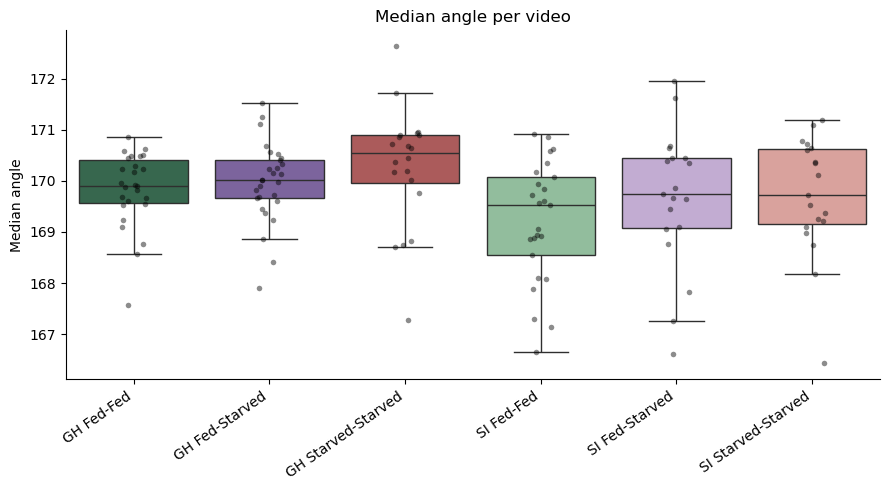

In [4]:
# summary per video, so videos with more frames do not dominate
file_angles = df.groupby(['Condition', 'Housing', 'Feeding', 'file']).agg(
    median_angle=('angle', 'median'),
    mean_angle=('angle', 'mean'),
).reset_index()

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=file_angles,
    x='Condition',
    y='median_angle',
    order=condition_order,
    palette=palette,
    showfliers=False,
)
sns.stripplot(
    data=file_angles,
    x='Condition',
    y='median_angle',
    order=condition_order,
    color='black',
    alpha=0.45,
    size=4,
)
plt.xticks(rotation=35, ha='right')
plt.ylabel('Median angle')
plt.xlabel('')
plt.title('Median angle per video')
sns.despine()
plt.tight_layout()
plt.show()
